# 🔍 Diagnostic de Complétude des Données IRC

**Objectif:** Comprendre pourquoi certaines années IRC ont beaucoup de pays manquants

**Analyse:**
1. Couverture temporelle par indicateur
2. Complétude par pilier IRC
3. Nombre de pays disponibles par année
4. Identification des goulots d'étranglement
5. Recommandations pour améliorer la couverture

In [32]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


## 1. Connexion à la Base de Données

In [33]:
# Connexion PostgreSQL
conn = psycopg2.connect(
    dbname="worlddatavision",
    user="elias",
    password="MaBaseDeDonnee",
    host="localhost",
    port="5432"
)

print("✅ Connecté à la base de données PostgreSQL")

# Vérifier les tables disponibles
query = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public' 
  AND table_name LIKE '%irc%' OR table_name LIKE '%indicator%'
ORDER BY table_name;
"""

tables = pd.read_sql(query, conn)
print("\n📊 Tables disponibles:")
print(tables)

✅ Connecté à la base de données PostgreSQL

📊 Tables disponibles:
           table_name
0           indicator
1  indicator_category
2     indicator_value


/tmp/ipykernel_82198/27819707.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query, conn)


## 2. Inventaire des Indicateurs IRC

In [34]:
# D'abord, vérifier la structure de la table indicator
schema_query = """
SELECT column_name, data_type
FROM information_schema.columns
WHERE table_name = 'indicator'
ORDER BY ordinal_position;
"""

schema_df = pd.read_sql(schema_query, conn)
print("📋 Colonnes de la table 'indicator':")
print(schema_df)
print("\n" + "="*50 + "\n")

# Récupérer tous les indicateurs IRC avec leurs catégories
query = """
SELECT 
    i.code,
    i.name,
    i.category_id
FROM indicator i
ORDER BY i.category_id, i.code;
"""

indicators_df = pd.read_sql(query, conn)

print(f"📊 Total indicateurs: {len(indicators_df)}")
print(f"\n🏛️ Répartition par catégorie:")
print(indicators_df['category_id'].value_counts().sort_index())

indicators_df.head(10)

📋 Colonnes de la table 'indicator':
   column_name          data_type
0           id            integer
1         code  character varying
2         name  character varying
3  description               text
4         unit  character varying
5  category_id            integer
6       source  character varying


📊 Total indicateurs: 76

🏛️ Répartition par catégorie:
1    10
2     8
3    14
4     8
5     3
6     9
7    12
8    11
9     1
Name: category_id, dtype: int64


/tmp/ipykernel_82198/3142624931.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  schema_df = pd.read_sql(schema_query, conn)
/tmp/ipykernel_82198/3142624931.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  indicators_df = pd.read_sql(query, conn)


,code,name,category_id
0,BN.CAB.XOKA.GD.ZS,Balance courante,1
1,BX.KLT.DINV.WD.GD.ZS,Investissements directs étrangers,1
2,DT.DOD.DECT.GN.ZS,Dette externe,1
3,DT.TDS.DECT.EX.ZS,Service de la dette,1
4,FI.RES.TOTL.MO,Réserves de change,1
5,FP.CPI.TOTL.ZG,Inflation,1
6,MS.MIL.XPND.GD.ZS,Dépenses militaires,1
7,NY.GDP.MKTP.KD.ZG,Croissance du PIB,1
8,NY.GDP.PCAP.PP.KD,"PIB par habitant (PPA, $ internationaux consta...",1
9,SL.UEM.TOTL.ZS,Taux de chômage,1


## 3. Analyse de la Couverture Temporelle par Indicateur

/tmp/ipykernel_82198/2767140697.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  temporal_df = pd.read_sql(query, conn)


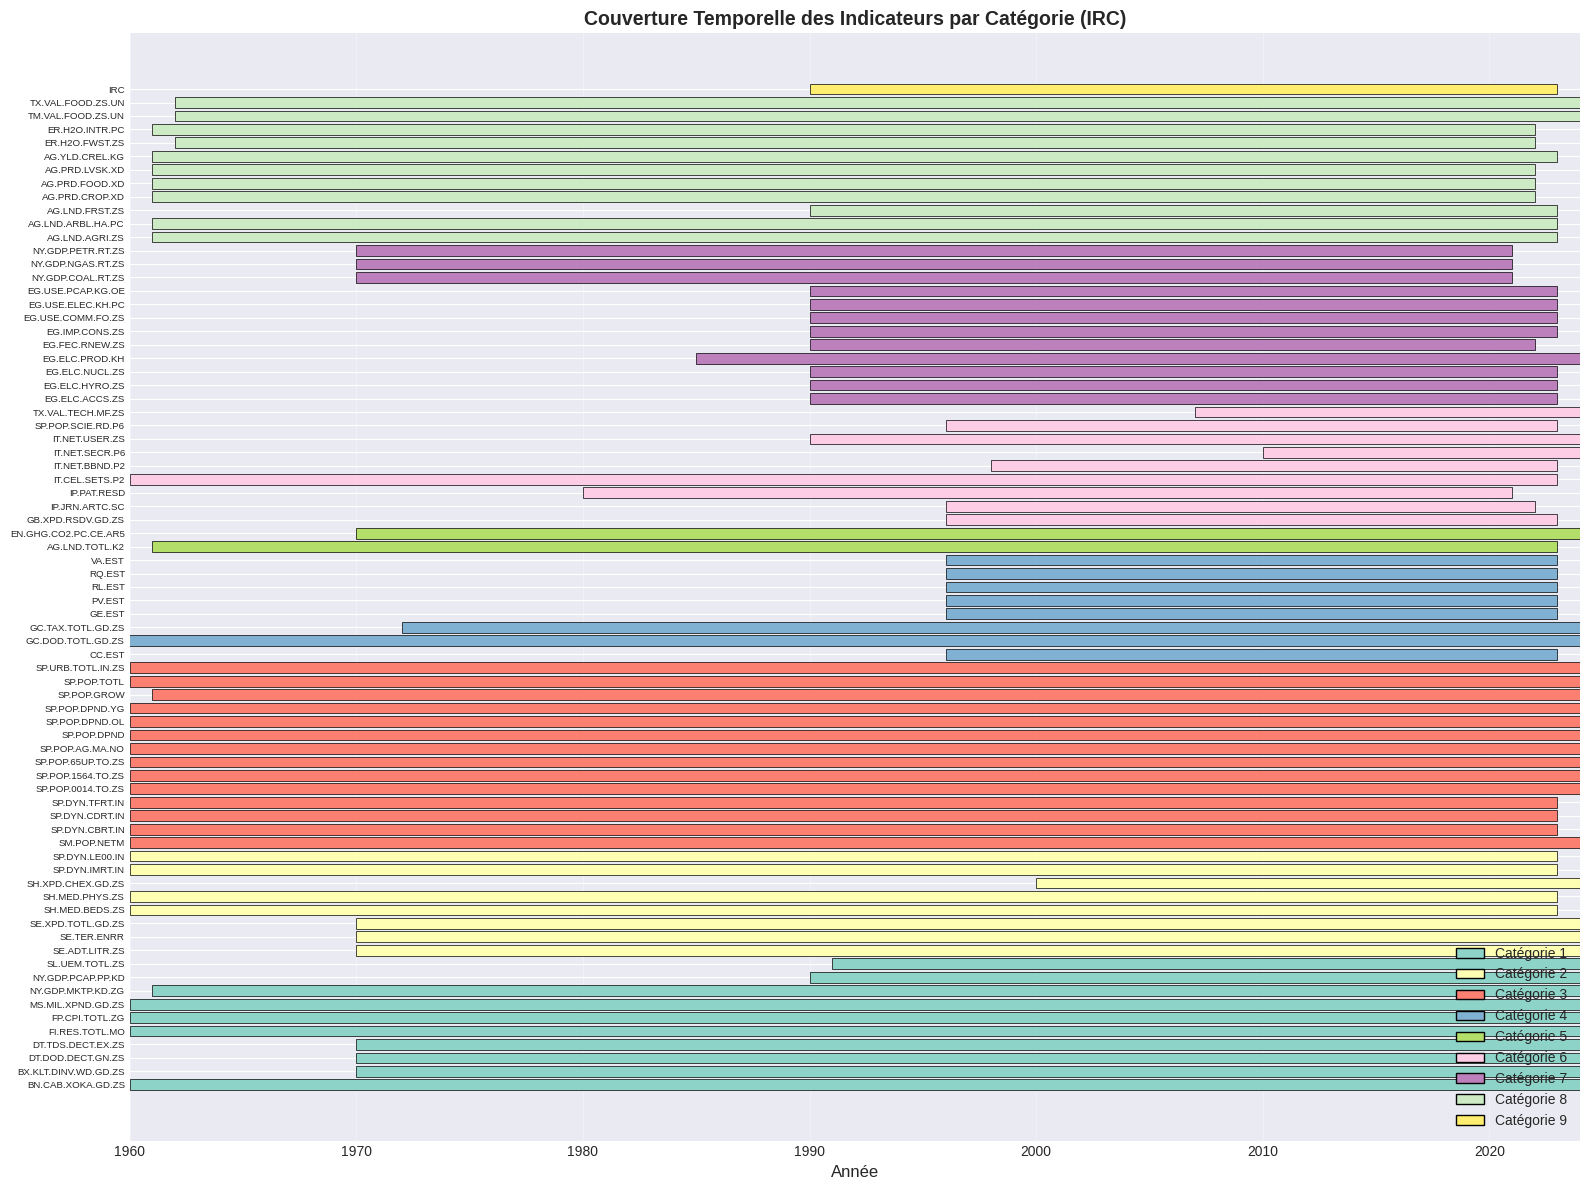


📊 Statistiques de couverture temporelle (sans EN.ATM.CO2E.PC):
  • Année la plus ancienne: 1950
  • Année la plus récente: 2025
  • Durée moyenne de couverture: 49.2 ans


In [35]:
# Visualiser la couverture temporelle
# D'abord, récupérer les années min/max pour chaque indicateur
query = """
SELECT 
    i.code,
    i.category_id,
    MIN(iv.year) as first_year,
    MAX(iv.year) as last_year,
    COUNT(DISTINCT iv.country_id) as country_count
FROM indicator i
LEFT JOIN indicator_value iv ON i.id = iv.indicator_id
WHERE i.code != 'EN.ATM.CO2E.PC'
GROUP BY i.id, i.code, i.category_id
ORDER BY i.category_id, i.code;
"""

temporal_df = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(16, 12))

# Créer un diagramme de Gantt pour chaque indicateur
categories = temporal_df['category_id'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
color_map = dict(zip(sorted(categories), colors))

for idx, row in temporal_df.iterrows():
    if pd.notna(row['first_year']) and pd.notna(row['last_year']):
        start = int(row['first_year'])
        end = int(row['last_year'])
        ax.barh(idx, end - start, left=start, height=0.8, 
                color=color_map[row['category_id']], 
                edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(temporal_df)))
ax.set_yticklabels(temporal_df['code'], fontsize=7)
ax.set_xlabel('Année', fontsize=12)
ax.set_title('Couverture Temporelle des Indicateurs par Catégorie (IRC)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(1960, 2024)

# Légende
legend_elements = [plt.Rectangle((0,0),1,1, fc=color_map[cat], edgecolor='black', label=f'Catégorie {cat}') 
                   for cat in sorted(categories)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 Statistiques de couverture temporelle (sans EN.ATM.CO2E.PC):")
print(f"  • Année la plus ancienne: {temporal_df['first_year'].min()}")
print(f"  • Année la plus récente: {temporal_df['last_year'].max()}")
print(f"  • Durée moyenne de couverture: {(temporal_df['last_year'] - temporal_df['first_year']).mean():.1f} ans")

## 4. Nombre de Pays Disponibles par Année et par Pilier

/tmp/ipykernel_82198/1318103124.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  coverage_df = pd.read_sql(query, conn)


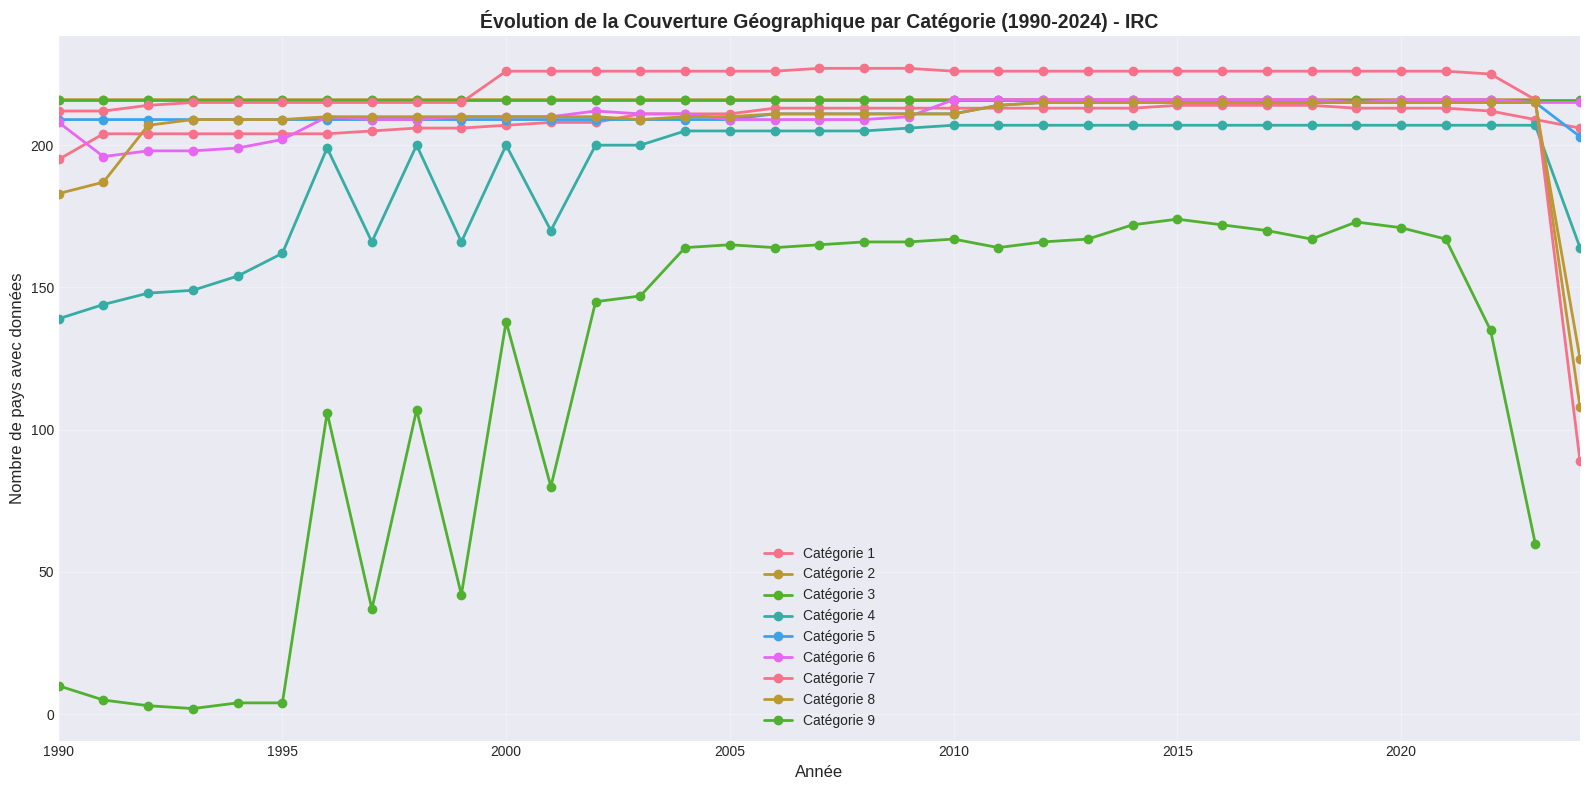


📊 Couverture par catégorie (dernière année, sans EN.ATM.CO2E.PC):
     category_id  nb_countries
314            7            35


In [36]:
# Analyser la disponibilité des données année par année
query = """
WITH yearly_coverage AS (
    SELECT 
        iv.year,
        i.category_id,
        COUNT(DISTINCT iv.country_id) as nb_countries,
        COUNT(DISTINCT i.code) as nb_indicators,
        COUNT(*) as nb_values
    FROM indicator_value iv
    JOIN indicator i ON iv.indicator_id = i.id
    WHERE i.code != 'EN.ATM.CO2E.PC'
      AND iv.year >= 1990
    GROUP BY iv.year, i.category_id
)
SELECT * FROM yearly_coverage
ORDER BY year, category_id;
"""

coverage_df = pd.read_sql(query, conn)

# Pivoter pour avoir les catégories en colonnes
pivot_countries = coverage_df.pivot(index='year', columns='category_id', values='nb_countries')

# Graphique d'évolution
fig, ax = plt.subplots(figsize=(16, 8))

for col in pivot_countries.columns:
    ax.plot(pivot_countries.index, pivot_countries[col], marker='o', label=f'Catégorie {col}', linewidth=2)

ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Nombre de pays avec données', fontsize=12)
ax.set_title('Évolution de la Couverture Géographique par Catégorie (1990-2024) - IRC', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(1990, 2024)

plt.tight_layout()
plt.show()

print("\n📊 Couverture par catégorie (dernière année, sans EN.ATM.CO2E.PC):")
last_year = coverage_df['year'].max()
if last_year is not None:
    last_year_data = coverage_df[coverage_df['year'] == last_year]
    print(last_year_data[['category_id', 'nb_countries']].sort_values('nb_countries', ascending=False))

## 5. Identification des Goulots d'Étranglement

In [37]:
# Trouver les indicateurs avec la plus faible couverture (excluant EN.ATM.CO2E.PC)
print("🚨 TOP 10 des indicateurs avec la couverture la plus FAIBLE (IRC):")
print("="*80)

low_coverage_query = """
SELECT 
    i.code,
    i.name,
    i.category_id,
    COUNT(DISTINCT iv.country_id) as country_count,
    MIN(iv.year) as first_year,
    MAX(iv.year) as last_year
FROM indicator i
LEFT JOIN indicator_value iv ON i.id = iv.indicator_id
WHERE i.code != 'EN.ATM.CO2E.PC'
GROUP BY i.id, i.code, i.name, i.category_id
ORDER BY country_count ASC
LIMIT 10;
"""

low_coverage = pd.read_sql(low_coverage_query, conn)
for idx, row in low_coverage.iterrows():
    print(f"\n📌 {row['code']}")
    print(f"   Nom: {row['name'][:60]}...")
    print(f"   Catégorie: {row['category_id']}")
    print(f"   Pays: {row['country_count']} | Période: {int(row['first_year']) if pd.notna(row['first_year']) else 'N/A'}-{int(row['last_year']) if pd.notna(row['last_year']) else 'N/A'}")

# Analyser la complétude par catégorie pour une année récente
print("\n\n📊 Analyse détaillée pour l'année 2020 (IRC):")
print("="*80)

query_2020 = """
SELECT 
    i.category_id,
    i.code,
    i.name,
    COUNT(DISTINCT iv.country_id) as nb_countries_2020
FROM indicator i
LEFT JOIN indicator_value iv ON i.id = iv.indicator_id AND iv.year = 2020
WHERE i.code != 'EN.ATM.CO2E.PC'
GROUP BY i.id, i.category_id, i.code, i.name
ORDER BY i.category_id, nb_countries_2020 ASC;
"""

coverage_2020 = pd.read_sql(query_2020, conn)

# Statistiques par catégorie
stats_by_category = coverage_2020.groupby('category_id')['nb_countries_2020'].agg(['min', 'mean', 'max'])
print("\nStatistiques de couverture par catégorie en 2020:")
print(stats_by_category.round(1))

🚨 TOP 10 des indicateurs avec la couverture la plus FAIBLE (IRC):

📌 DT.TDS.DECT.EX.ZS
   Nom: Service de la dette...
   Catégorie: 1
   Pays: 121 | Période: 1970-2024

📌 DT.DOD.DECT.GN.ZS
   Nom: Dette externe...
   Catégorie: 1
   Pays: 121 | Période: 1970-2024

📌 SP.POP.SCIE.RD.P6
   Nom: Chercheurs par million...
   Catégorie: 6
   Pays: 144 | Période: 1996-2023

📌 EG.IMP.CONS.ZS
   Nom: Importations nettes d'énergie...
   Catégorie: 7
   Pays: 145 | Période: 1990-2023

📌 EG.USE.ELEC.KH.PC
   Nom: Consommation d'électricité par habitant...
   Catégorie: 7
   Pays: 150 | Période: 1990-2023

📌 GB.XPD.RSDV.GD.ZS
   Nom: Dépenses R&D...
   Catégorie: 6
   Pays: 153 | Période: 1996-2023

📌 IP.PAT.RESD
   Nom: Demandes de brevets...
   Catégorie: 6
   Pays: 158 | Période: 1980-2021

📌 GC.TAX.TOTL.GD.ZS
   Nom: Revenus fiscaux (% du PIB)...
   Catégorie: 4
   Pays: 161 | Période: 1972-2024

📌 MS.MIL.XPND.GD.ZS
   Nom: Dépenses militaires...
   Catégorie: 1
   Pays: 164 | Période: 1960-202

/tmp/ipykernel_82198/2492935055.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  low_coverage = pd.read_sql(low_coverage_query, conn)
/tmp/ipykernel_82198/2492935055.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  coverage_2020 = pd.read_sql(query_2020, conn)



Statistiques de couverture par catégorie en 2020:
             min   mean  max
category_id                 
1            117  170.2  209
2             42  152.1  216
3            216  216.0  216
4            137  192.4  206
5            203  209.0  215
6             78  161.4  214
7            139  185.2  214
8            165  189.3  213
9            171  171.0  171


## 6. Calcul du Taux de Complétude IRC par Pays et par Année

In [38]:
# Calculer pour chaque pays et année : combien d'indicateurs IRC ont des données
query = """
WITH total_indicators AS (
    SELECT COUNT(*) as total
    FROM indicator
    WHERE code != 'EN.ATM.CO2E.PC'
),
country_coverage AS (
    SELECT 
        iv.country_id,
        iv.year,
        COUNT(DISTINCT iv.indicator_id) as indicators_available
    FROM indicator_value iv
    JOIN indicator i ON iv.indicator_id = i.id
    WHERE i.code != 'EN.ATM.CO2E.PC'
      AND iv.year >= 2010
    GROUP BY iv.country_id, iv.year
)
SELECT 
    country_id,
    year,
    indicators_available,
    total,
    ROUND(100.0 * indicators_available / total, 1) as completeness_pct
FROM country_coverage, total_indicators
ORDER BY year DESC, completeness_pct DESC;
"""

completeness_df = pd.read_sql(query, conn)

print(f"📊 Total d'enregistrements analysés: {len(completeness_df):,}")
print(f"\n🌍 Nombre total d'indicateurs IRC: {completeness_df['total'].iloc[0] if len(completeness_df) > 0 else 0}")

# Statistiques par année
print("\n📈 Évolution de la complétude moyenne par année (IRC):")
yearly_stats = completeness_df.groupby('year').agg({
    'completeness_pct': ['mean', 'median', 'min', 'max'],
    'country_id': 'count'
}).round(1)
yearly_stats.columns = ['Moyenne %', 'Médiane %', 'Min %', 'Max %', 'Nb Pays']
print(yearly_stats.tail(10))

📊 Total d'enregistrements analysés: 3,421

🌍 Nombre total d'indicateurs IRC: 75

📈 Évolution de la complétude moyenne par année (IRC):
      Moyenne %  Médiane %  Min %  Max %  Nb Pays
year                                             
2016       81.7       92.0    1.3  100.0      227
2017       81.8       92.0    1.3  100.0      227
2018       81.5       92.0    1.3  100.0      227
2019       81.5       92.0    1.3  100.0      227
2020       81.2       90.7    1.3  100.0      227
2021       80.9       92.0    1.3  100.0      227
2022       74.0       84.0    1.3   93.3      227
2023       64.1       68.0    2.7   84.0      218
2024       31.9       33.3    2.7   42.7      217
2025        1.3        1.3    1.3    1.3       35


/tmp/ipykernel_82198/3801584594.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  completeness_df = pd.read_sql(query, conn)


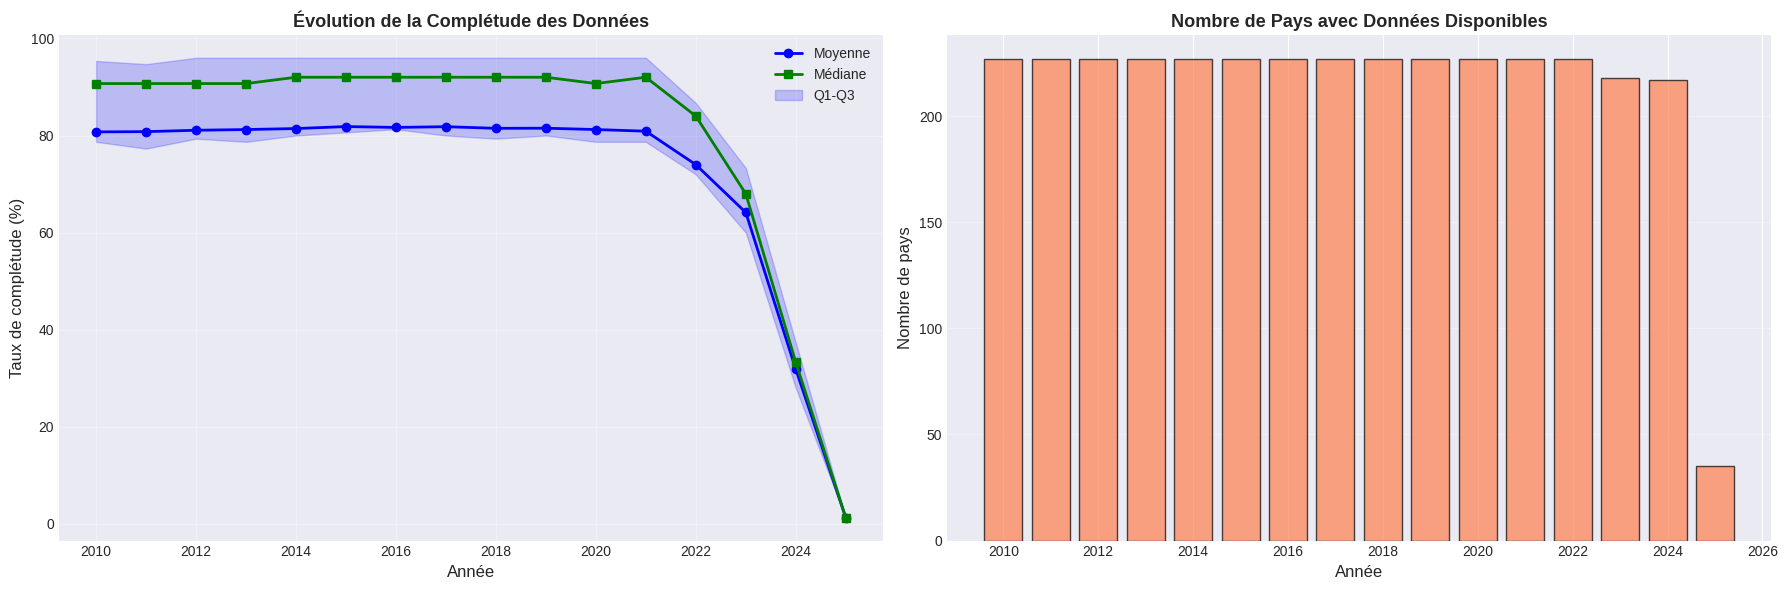

In [39]:
# Graphique d'évolution de la complétude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1: Évolution de la complétude moyenne
yearly_mean = completeness_df.groupby('year')['completeness_pct'].mean()
yearly_median = completeness_df.groupby('year')['completeness_pct'].median()
yearly_count = completeness_df.groupby('year')['country_id'].count()

ax1.plot(yearly_mean.index, yearly_mean.values, marker='o', linewidth=2, label='Moyenne', color='blue')
ax1.plot(yearly_median.index, yearly_median.values, marker='s', linewidth=2, label='Médiane', color='green')
ax1.fill_between(yearly_mean.index, 
                  completeness_df.groupby('year')['completeness_pct'].quantile(0.25),
                  completeness_df.groupby('year')['completeness_pct'].quantile(0.75),
                  alpha=0.2, color='blue', label='Q1-Q3')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Taux de complétude (%)', fontsize=12)
ax1.set_title('Évolution de la Complétude des Données', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Nombre de pays avec données
ax2.bar(yearly_count.index, yearly_count.values, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Nombre de pays', fontsize=12)
ax2.set_title('Nombre de Pays avec Données Disponibles', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Pays avec la Meilleure et Pire Couverture (2023)

🏆 TOP 10 des pays avec la MEILLEURE couverture en 2025:
Pays 646 |  1/75 indicateurs |   1.3%
Pays 602 |  1/75 indicateurs |   1.3%
Pays 654 |  1/75 indicateurs |   1.3%
Pays 701 |  1/75 indicateurs |   1.3%
Pays 733 |  1/75 indicateurs |   1.3%
Pays 562 |  1/75 indicateurs |   1.3%
Pays 520 |  1/75 indicateurs |   1.3%
Pays 726 |  1/75 indicateurs |   1.3%
Pays 559 |  1/75 indicateurs |   1.3%
Pays 513 |  1/75 indicateurs |   1.3%


⚠️ TOP 10 des pays avec la PIRE couverture en 2025:
Pays 646 |  1/75 indicateurs |   1.3%
Pays 602 |  1/75 indicateurs |   1.3%
Pays 654 |  1/75 indicateurs |   1.3%
Pays 701 |  1/75 indicateurs |   1.3%
Pays 733 |  1/75 indicateurs |   1.3%
Pays 562 |  1/75 indicateurs |   1.3%
Pays 520 |  1/75 indicateurs |   1.3%
Pays 726 |  1/75 indicateurs |   1.3%
Pays 559 |  1/75 indicateurs |   1.3%
Pays 513 |  1/75 indicateurs |   1.3%


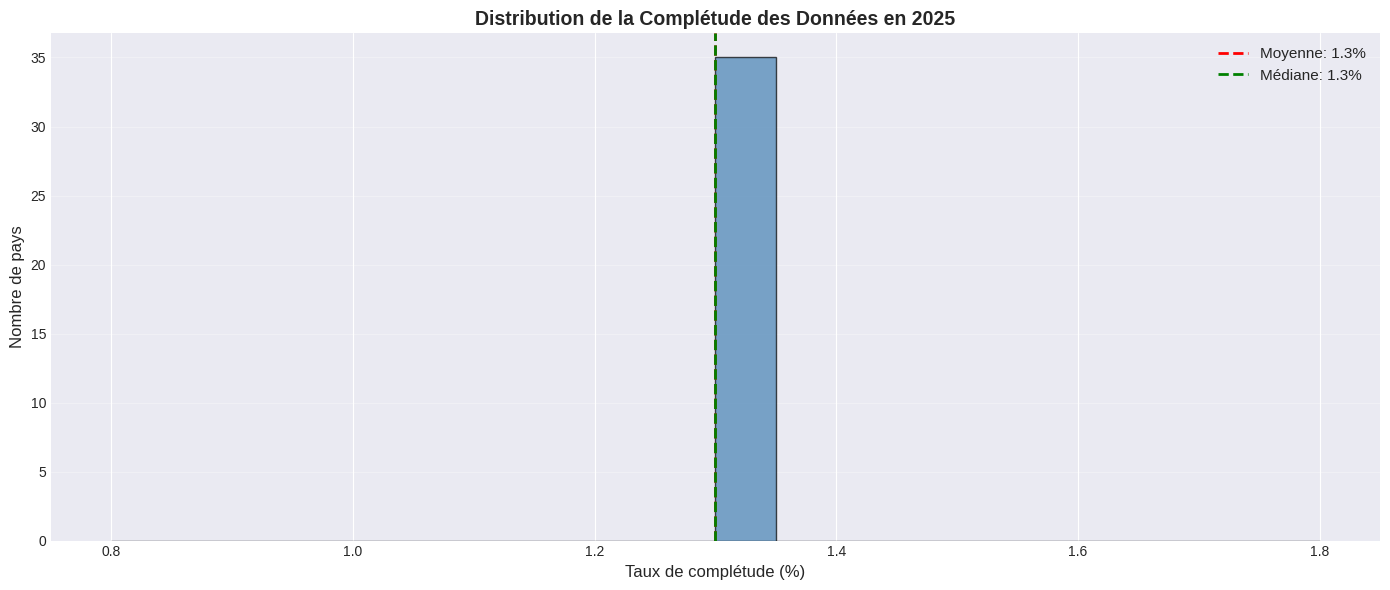

In [40]:
# Filtrer pour dernière année disponible
last_year_value = completeness_df['year'].max()
data_last_year = completeness_df[completeness_df['year'] == last_year_value]

if len(data_last_year) > 0:
    print(f"🏆 TOP 10 des pays avec la MEILLEURE couverture en {int(last_year_value)}:")
    print("="*80)
    top_countries = data_last_year.nlargest(10, 'completeness_pct')
    for idx, row in top_countries.iterrows():
        print(f"Pays {int(row['country_id']):3d} | {row['indicators_available']:2.0f}/{row['total']:2.0f} indicateurs | {row['completeness_pct']:5.1f}%")
    
    print(f"\n\n⚠️ TOP 10 des pays avec la PIRE couverture en {int(last_year_value)}:")
    print("="*80)
    bottom_countries = data_last_year.nsmallest(10, 'completeness_pct')
    for idx, row in bottom_countries.iterrows():
        print(f"Pays {int(row['country_id']):3d} | {row['indicators_available']:2.0f}/{row['total']:2.0f} indicateurs | {row['completeness_pct']:5.1f}%")
    
    # Histogramme de distribution
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.hist(data_last_year['completeness_pct'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(data_last_year['completeness_pct'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {data_last_year['completeness_pct'].mean():.1f}%")
    ax.axvline(data_last_year['completeness_pct'].median(), color='green', linestyle='--', linewidth=2, label=f"Médiane: {data_last_year['completeness_pct'].median():.1f}%")
    ax.set_xlabel('Taux de complétude (%)', fontsize=12)
    ax.set_ylabel('Nombre de pays', fontsize=12)
    ax.set_title(f'Distribution de la Complétude des Données en {int(last_year_value)}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Aucune donnée disponible")

## 8. Analyse des Indicateurs Manquants Critiques

📊 Analyse couverture IRC (2020):
Total pays: 227

Répartition:
OK             216
INSUFFISANT     11
Name: coverage_status, dtype: int64

✅ Pays avec bonne couverture (≥5 catégories): 216
❌ Pays avec couverture insuffisante (<5 catégories): 11


/tmp/ipykernel_82198/3596553633.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  coverage_check = pd.read_sql(query, conn)


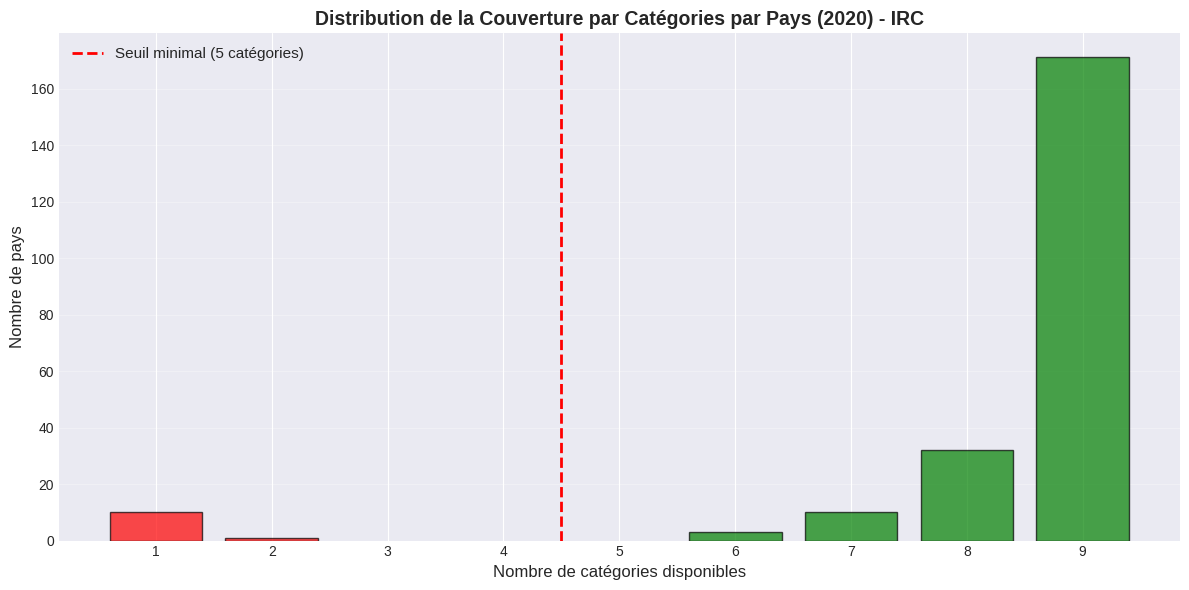

In [41]:
# Identifier les indicateurs qui ont des données et ceux qui manquent (IRC)
query = """
WITH indicator_coverage AS (
    SELECT 
        iv.country_id,
        iv.year,
        i.category_id,
        COUNT(DISTINCT i.code) as indicators_in_category
    FROM indicator_value iv
    JOIN indicator i ON iv.indicator_id = i.id
    WHERE i.code != 'EN.ATM.CO2E.PC'
      AND iv.year = 2020
    GROUP BY iv.country_id, iv.year, i.category_id
),
categories_per_country AS (
    SELECT 
        country_id,
        year,
        COUNT(DISTINCT category_id) as categories_available
    FROM indicator_coverage
    WHERE indicators_in_category > 0
    GROUP BY country_id, year
)
SELECT 
    country_id,
    categories_available,
    CASE WHEN categories_available >= 5 THEN 'OK' ELSE 'INSUFFISANT' END as coverage_status
FROM categories_per_country
ORDER BY categories_available DESC, country_id;
"""

coverage_check = pd.read_sql(query, conn)

print("📊 Analyse couverture IRC (2020):")
print("="*80)
print(f"Total pays: {len(coverage_check)}")
print(f"\nRépartition:")
print(coverage_check['coverage_status'].value_counts())

print(f"\n✅ Pays avec bonne couverture (≥5 catégories): {len(coverage_check[coverage_check['categories_available'] >= 5])}")
print(f"❌ Pays avec couverture insuffisante (<5 catégories): {len(coverage_check[coverage_check['categories_available'] < 5])}")

# Graphique
fig, ax = plt.subplots(figsize=(12, 6))
category_counts = coverage_check['categories_available'].value_counts().sort_index()
colors = ['red' if x < 5 else 'green' for x in category_counts.index]
ax.bar(category_counts.index, category_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.axvline(4.5, color='red', linestyle='--', linewidth=2, label='Seuil minimal (5 catégories)')
ax.set_xlabel('Nombre de catégories disponibles', fontsize=12)
ax.set_ylabel('Nombre de pays', fontsize=12)
ax.set_title('Distribution de la Couverture par Catégories par Pays (2020) - IRC', fontsize=14, fontweight='bold')
ax.set_xticks(range(int(category_counts.index.min()), int(category_counts.index.max())+1))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Recommandations pour Améliorer la Couverture

In [42]:
print("🎯 RECOMMANDATIONS POUR AMÉLIORER LA COUVERTURE DES DONNÉES IRC")
print("="*80)

# Analyser les indicateurs les plus problématiques par catégorie (excluant EN.ATM.CO2E.PC)
for category_id in sorted(coverage_2020['category_id'].unique()):
    category_indicators = coverage_2020[coverage_2020['category_id'] == category_id]
    worst_indicator = category_indicators.nsmallest(1, 'nb_countries_2020').iloc[0]
    
    print(f"\n📌 Catégorie: {category_id}")
    print(f"   Indicateur le plus manquant: {worst_indicator['code']}")
    print(f"   Couverture: {worst_indicator['nb_countries_2020']} pays en 2020")
    print(f"   Impact: {'🔴 CRITIQUE' if worst_indicator['nb_countries_2020'] < 50 else '🟡 IMPORTANT' if worst_indicator['nb_countries_2020'] < 100 else '🟢 MINEUR'}")

print("\n\n💡 STRATÉGIES D'AMÉLIORATION:")
print("="*80)
print("""
1. IMPUTATION INTELLIGENTE
   ✓ Utiliser la régression pour estimer les valeurs manquantes
   ✓ Imputation par voisins géographiques (même région)
   ✓ Interpolation temporelle (années adjacentes)

2. RÉDUIRE LE NOMBRE D'INDICATEURS
   ✓ Garder uniquement les indicateurs avec >150 pays
   ✓ Remplacer indicateurs rares par des proxies plus courants
   ✓ Exemple: Remplacer certains indicateurs rares par alternatives

3. AJUSTER LES SEUILS DE CALCUL
   ✓ Actuellement: 5 catégories sur 8 requis (EN.ATM.CO2E.PC exclus)
   ✓ Option souple: 4 catégories sur 8 pour années anciennes
   ✓ Ou: pondération dynamique (catégories disponibles comptent plus)

4. CIBLER LES ANNÉES OPTIMALES
   ✓ Concentrer l'analyse sur 2010-2020 (meilleure couverture)
   ✓ Éviter années avant 2000 (données très incomplètes)
   ✓ Utiliser année de référence commune (ex: 2015, 2019)

5. SOURCES DE DONNÉES ALTERNATIVES
   ✓ Croiser avec d'autres bases (OECD, Eurostat, IMF)
   ✓ Utiliser des estimations FMI/ONU quand World Bank manque
   ✓ Intégrer données régionales (AfDB, ADB, etc.)
""")

print("\n🔧 Action immédiate recommandée:")
print("-" * 80)
print("Créer une vue SQL qui filtre les indicateurs IRC (sans EN.ATM.CO2E.PC) avec couverture suffisante")

🎯 RECOMMANDATIONS POUR AMÉLIORER LA COUVERTURE DES DONNÉES IRC

📌 Catégorie: 1
   Indicateur le plus manquant: DT.TDS.DECT.EX.ZS
   Couverture: 117 pays en 2020
   Impact: 🟢 MINEUR

📌 Catégorie: 2
   Indicateur le plus manquant: SE.ADT.LITR.ZS
   Couverture: 42 pays en 2020
   Impact: 🔴 CRITIQUE

📌 Catégorie: 3
   Indicateur le plus manquant: SP.POP.DPND.OL
   Couverture: 216 pays en 2020
   Impact: 🟢 MINEUR

📌 Catégorie: 4
   Indicateur le plus manquant: GC.TAX.TOTL.GD.ZS
   Couverture: 137 pays en 2020
   Impact: 🟢 MINEUR

📌 Catégorie: 5
   Indicateur le plus manquant: EN.GHG.CO2.PC.CE.AR5
   Couverture: 203 pays en 2020
   Impact: 🟢 MINEUR

📌 Catégorie: 6
   Indicateur le plus manquant: SP.POP.SCIE.RD.P6
   Couverture: 78 pays en 2020
   Impact: 🟡 IMPORTANT

📌 Catégorie: 7
   Indicateur le plus manquant: EG.IMP.CONS.ZS
   Couverture: 139 pays en 2020
   Impact: 🟢 MINEUR

📌 Catégorie: 8
   Indicateur le plus manquant: TX.VAL.FOOD.ZS.UN
   Couverture: 165 pays en 2020
   Impact: 🟢 MIN

## 10. Export des Résultats

In [43]:
# Sauvegarder les résultats pour référence (IRC uniquement, sans EN.ATM.CO2E.PC)
output_dir = '/home/elias/PROJECT/WorldDataVision/analysis_outputs'
import os
os.makedirs(output_dir, exist_ok=True)

# Export 1: Complétude par pays (dernière année)
last_year = completeness_df['year'].max()
if last_year is not None:
    data_last_year = completeness_df[completeness_df['year'] == last_year]
    data_last_year.to_csv(f'{output_dir}/completeness_irc_{last_year}.csv', index=False)
    print(f"✅ Exporté: completeness_irc_{last_year}.csv ({len(data_last_year)} pays)")

# Export 2: Indicateurs problématiques IRC
low_coverage.to_csv(f'{output_dir}/low_coverage_irc_indicators.csv', index=False)
print(f"✅ Exporté: low_coverage_irc_indicators.csv ({len(low_coverage)} indicateurs)")

# Export 3: Évolution temporelle
if len(yearly_stats) > 0:
    yearly_stats.to_csv(f'{output_dir}/yearly_coverage_irc_stats.csv')
    print(f"✅ Exporté: yearly_coverage_irc_stats.csv")

print(f"\n📁 Tous les fichiers sauvegardés dans: {output_dir}")
print("ℹ️ Note: EN.ATM.CO2E.PC exclu de toutes les analyses IRC")

# Fermer la connexion
conn.close()
print("\n✅ Analyse terminée - Connexion fermée")

✅ Exporté: completeness_irc_2025.csv (35 pays)
✅ Exporté: low_coverage_irc_indicators.csv (10 indicateurs)
✅ Exporté: yearly_coverage_irc_stats.csv

📁 Tous les fichiers sauvegardés dans: /home/elias/PROJECT/WorldDataVision/analysis_outputs
ℹ️ Note: EN.ATM.CO2E.PC exclu de toutes les analyses IRC

✅ Analyse terminée - Connexion fermée
